1.IMPORTING LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

import pickle


2.LOAD DATASET

In [3]:
df= pd.read_csv("C:\\Users\\ARYAN\\Desktop\\MiniProject\\Supply-Chain-Inventory-Optimizer-Using-AI\\data\\retail_store_inventory.csv")

In [4]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


3.DATA OVERVIEW

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  str    
 1   Store ID            73100 non-null  str    
 2   Product ID          73100 non-null  str    
 3   Category            73100 non-null  str    
 4   Region              73100 non-null  str    
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  str    
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  str    
dtypes: float64(3), int64(5), str(7)
memory usage: 8.4 MB


4.DATA CLEANING

In [6]:
#DUPLICATE ROWS REMOVE
df.shape

df.drop_duplicates(inplace=True)

df.shape


(73100, 15)

In [7]:
# Date Column Clean & Convert
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [8]:
df['Date'].isnull().sum()


np.int64(0)

In [9]:
#MISSING VALUES HANDLE
df.isnull().sum()


Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

Numerical Columns Fill

In [10]:
num_cols = [
    'Inventory Level', 'Units Sold', 'Units Ordered',
    'Demand Forecast', 'Price', 'Discount', 'Competitor Pricing'
]

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)


C:\Users\ARYAN\AppData\Local\Temp\ipykernel_19768\4260528387.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].mean(), inplace=True)


Categorical Columns Fill

In [11]:
cat_cols = [
    'Store ID', 'Product ID', 'Category',
    'Region', 'Weather Condition', 'Seasonality'
]

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


C:\Users\ARYAN\AppData\Local\Temp\ipykernel_19768\1010550112.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].mode()[0], inplace=True)


Sort Data by Date (Time Series Rule)

In [12]:
df = df.sort_values('Date')


Remove Invalid Values (Logical Cleaning)

In [13]:
(df['Units Sold'] < 0).sum()


np.int64(0)

In [14]:
df = df[df['Units Sold'] >= 0]


In [15]:
df = df[df['Inventory Level'] >= 0]


 Outlier Treatment

5.BASIC EDA

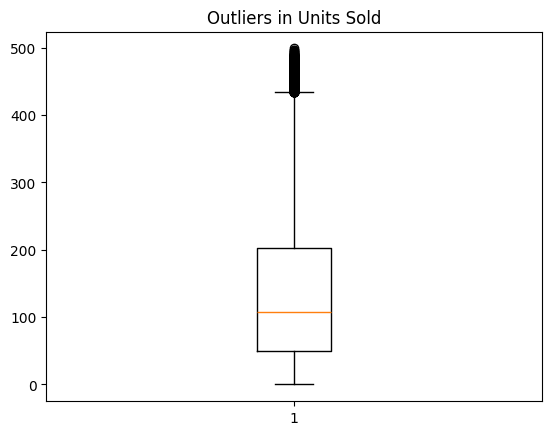

In [16]:
plt.boxplot(df['Units Sold'])
plt.title("Outliers in Units Sold")
plt.show()


In [17]:
Q1 = df['Units Sold'].quantile(0.25)
Q3 = df['Units Sold'].quantile(0.75)
IQR = Q3 - Q1

df = df[
    (df['Units Sold'] >= Q1 - 1.5 * IQR) &
    (df['Units Sold'] <= Q3 + 1.5 * IQR)
]


STEP 6: Feature Engineering

In [18]:
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year


Encode Categorical Features

In [19]:
df_encoded = pd.get_dummies(
    df,
    columns=['Category', 'Region', 'Weather Condition', 'Seasonality'],
    drop_first=True
)


In [20]:
df_encoded.drop(['Store ID', 'Product ID'], axis=1, inplace=True)


Final Check (CLEAN DATA READY)

In [21]:
df_encoded.info()


<class 'pandas.DataFrame'>
Index: 72385 entries, 0 to 73099
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     72385 non-null  datetime64[us]
 1   Inventory Level          72385 non-null  int64         
 2   Units Sold               72385 non-null  int64         
 3   Units Ordered            72385 non-null  int64         
 4   Demand Forecast          72385 non-null  float64       
 5   Price                    72385 non-null  float64       
 6   Discount                 72385 non-null  int64         
 7   Holiday/Promotion        72385 non-null  int64         
 8   Competitor Pricing       72385 non-null  float64       
 9   Day                      72385 non-null  int32         
 10  Month                    72385 non-null  int32         
 11  Year                     72385 non-null  int32         
 12  Category_Electronics     72385 non-null  bool   

STEP 7.INPUT (X) & OUTPUT(Y)

In [22]:
X = df_encoded.drop(['Units Sold', 'Date'], axis=1)
y = df_encoded['Units Sold']


8.TRAIN TEST SPLIT

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


STEP 9:TRAIN MODEL

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


STEP 10: PREDICTION

In [25]:
y_pred = model.predict(X_test)


STEP 11: MODEL EVALUATION

In [26]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 7.4402989011263045
R2 Score: 0.993234592978687


STEP 12: SAVE TRAINED MODEL


In [27]:
import pickle

with open("../model/demand_model.pkl", "wb") as f:
    pickle.dump(model, f)
